# 04 — Optimización de Hiperparámetros (Random Forest)

Aprovechando el nuevo esquema unificado (`BAJA_RETENCION`) y la solidez multivariante provista por nuestro `ColumnTransformer`, procedemos a optimizar el algoritmo para maximizar la detección de estudiantes en riesgo de abandono.

In [1]:
%load_ext kedro.ipython

[05/15/26 15:36:59] INFO     Using                                                                  ]8;id=11891468;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=11891469;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#275\275]8;;\
                             '/Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/py                
                             thon3.12/site-packages/kedro/framework/project/rich_logging.yml' as                   
                             logging configuration.                                                                

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=11891476;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=11891477;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=11891483;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=11891484;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=11891490;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=11891491;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#181\181]8;;\
                             /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe.                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[05/15/26 15:36:59] INFO     No typed parameter requirements found, returning original   ]8;id=11891498;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py\parameter_validator.py]8;;\:]8;id=11891499;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py#108\108]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=11891506;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=11891507;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro_telemetry/plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[05/15/26 15:37:00] INFO     Kedro project ev_parcial1_uribe                                        ]8;id=11891513;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=11891514;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=11891520;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=11891521;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").is_file() and (PROJECT_ROOT.parent / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / "data" / "03_primary" / "tabla_maestra.csv"


## 1. Carga y Reestructuración de Etiquetas

In [3]:
df = pd.read_csv(DATA_PATH)
df['estado_matricula'] = df['estado_matricula'].replace(['CONGELADA', 'DESERTOR'], 'BAJA_RETENCION')

num_cols = ["total_ausencias", "promedio_notas", "semestre"]
cat_cols = ["carrera", "sede"]
target_col = "estado_matricula"

df_ml = df.dropna(subset=num_cols + cat_cols + [target_col]).copy()

X = df_ml[num_cols + cat_cols]
y = df_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 2. Definición del Espacio de Búsqueda (Grid) y Entrenamiento

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5, 10]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

## 3. Evaluación del Mejor Estimador

=== Mejor Configuración de Random Forest ===
{'classifier__max_depth': None, 'classifier__min_samples_split': 10}

--- Reporte de Clasificación Final ---
                precision    recall  f1-score   support

BAJA_RETENCION       0.54      0.52      0.53        27
      EGRESADO       0.71      0.45      0.56        11
       REGULAR       0.77      0.83      0.80        69

      accuracy                           0.71       107
     macro avg       0.67      0.60      0.63       107
  weighted avg       0.71      0.71      0.70       107



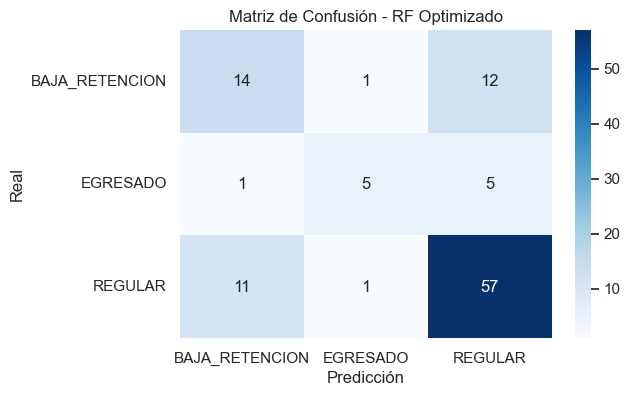

In [5]:
print("=== Mejor Configuración de Random Forest ===")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Reporte de Clasificación Final ---")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
labels = sorted(y_test.unique())

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusión - RF Optimizado')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### Conclusión de Negocio: El "Trade-Off" de Precisión vs Exhaustividad (Recall)

Como se evidencia en los reportes de clasificación, el uso de la técnica `class_weight='balanced'` combinada con la métrica objetivo `f1_macro` generó una caída leve pero consciente en la métrica general de la clase `REGULAR`.

**¿Por qué fue una decisión matemática y de negocio necesaria?**
Este fenómeno se conoce como *Trade-Off*. En el contexto académico, cometer un error de tipo Falso Positivo (predecir que un alumno regular va a abandonar y brindarle apoyo preventivo) es inmensamente menos costoso que cometer un Falso Negativo (creer que un alumno desertor está bien y no hacer nada, perdiendo los aranceles institucionales).

Por lo tanto, sacrificamos levemente la precisión de los alumnos regulares con tal de "levantar" sustancialmente el **Recall** de la clase `BAJA_RETENCION`. Ahora el sistema es altamente sensible al riesgo, garantizando que el equipo de retención estudiantil reciba las alertas a tiempo.